In [1]:
import jax
jax.config.update('jax_enable_x64', True)  # Use float64
jax.config.update("jax_default_matmul_precision", "highest")

import inference
import models
import visualizations
import utils

import numpy as np
import jax.numpy as jnp
import numpyro
from numpyro import optim
import matplotlib.pyplot as plt


# Load

In [2]:
from scipy.io import loadmat

#import data
SATED_DECONV = np.load('../Data/predictions_fullTrace_sated.npy', allow_pickle=True)
ANG_STIM_DATA = loadmat('../Data/metadata_deconv/stimAngle_sated.mat', simplify_cells=True)
SF_STIM_DATA  = loadmat('../Data/metadata_deconv/stimSpatFreq_sated.mat', simplify_cells=True)
SATED_ANGLE = ANG_STIM_DATA['order_of_stim_arossAnimals']
SATED_SF    = SF_STIM_DATA['stimSpatFreq_arossAnimals']

HUNGRY_DECONV = np.load('../Data/predictions_fullTrace_hungry.npy', allow_pickle=True)
ANG_STIM_DATA_HUNGRY = loadmat('../Data/metadata_deconv/stimAngle_hungry.mat', simplify_cells=True)
SF_STIM_DATA_HUNGRY  = loadmat('../Data/metadata_deconv/stimSpatFreq_hungry.mat', simplify_cells=True)
HUNGRY_ANGLE = ANG_STIM_DATA_HUNGRY['order_of_stim_arossAnimals']
HUNGRY_SF    = SF_STIM_DATA_HUNGRY['stimSpatFreq_arossAnimals']

def resort_preprocessing(datum,angle_arr,sf_arr,animal):
    data = np.copy(datum[animal,:])
    neurons = data[0].shape[0]
    reshape_data = np.full((60,neurons,data[0].shape[1]), np.nan)
    for i in range(60):
        reshape_data[i,:,:] = data[i]

    reshape_data = reshape_data.reshape(60,neurons,12,120)
    reshape_data = np.transpose(reshape_data,(1,2,0,3))
    #Remove first two neurons
    reshape_data = reshape_data[2:,:,:,:]

    #Remove None trials
    max_trial = np.argmax(np.isnan(reshape_data[0,1,:,0]))
    reshape_data = reshape_data[:,:,:max_trial,:]

    # Remove beginning and last bit # HMMMM should I do this?
    # reshape_data[:,0,:,:32] = np.nan
    # reshape_data[:,-1,:,88:] = np.nan
    # print(np.any(np.isnan(reshape_data)))
    # print(reshape_data.shape)
    
    # Reorder angles
    angles = np.copy(angle_arr[animal])
    for itrials in range(angles.shape[1]):
        order = angles[:,itrials]-1
        reshape_data[:,:,itrials,:] = reshape_data[:,order,itrials,:]

    # Reorder SFs
    reshaped_data = []
    sfs = np.copy(sf_arr[animal])
    for experiment in range(1,6):
        mask = sfs == experiment
        reshaped_data.append(reshape_data[:,:,mask,:])

    max_trials = max([exp.shape[2] for exp in reshaped_data])
    # Pad the data for experiments with (10, 12, 80)fewer trials
    for i in range(len(reshaped_data)):
        if reshaped_data[i].shape[2] < max_trials:
            padding = max_trials - reshaped_data[i].shape[2]
            reshaped_data[i] = np.pad(reshaped_data[i], ((0, 0),(0, 0),(0, padding),(0, 0)), mode='constant', constant_values=np.nan)

    reshaped_data = np.stack(reshaped_data,axis=2)    

    return reshaped_data



def remove_neurons(datum, angles,sfs, animal, count = False):
    neurons_to_keep = []
    data = resort_preprocessing(datum,angles,sfs,animal)
    number_neurons = data.shape[0]    
    for i in range(number_neurons):
        # print(np.nanmean(data[i, :, :, :, 40:80], axis = 3))
        stim_average = np.nanmean(data[i, :, :, :, 40:80], axis = 3) # OKAY TO NOT HAVE NANMEAN?
        best_sf = np.argmax(np.nanmean(stim_average, axis = (0,2))).astype('int')
        best_angle = np.argmax(np.nanmean(stim_average[:,best_sf,:], axis = 1)).astype('int')
        averaged_calcium = np.nanmean(stim_average[best_angle,best_sf,:])
        
        grey_data = data[i, :, :, :, 0:20]
        # grey_data = np.concatenate((data[i, :, :, :, 0:40], data[i, :, :, :, 80:]), axis = 3)
        grey_average = np.nanmean(grey_data, axis = 3)
        best_sf = np.argmax(np.nanmean(grey_average, axis = (0,2))).astype(int)
        best_angle = np.argmax(np.nanmean(grey_average[:,best_sf,:], axis = 1)).astype(int)
        average_grey = np.nanmean(grey_average[best_angle,best_sf,:])
        std_grey = np.nanstd(grey_average[best_angle,best_sf,:])
        
        if np.abs(averaged_calcium - average_grey) >= 1.69*std_grey:
            neurons_to_keep.append(i)
    
    # Keep only the neurons that meet the condition
    data_filtered = data[neurons_to_keep, :, :,:,:]
    if count:
        return data_filtered.shape[0]/data.shape[0]

    return data_filtered

ANIMAL = 0
# Average across time and collapse (angle, sf) into a flat condition axis
TEST_DATA2D = resort_preprocessing(SATED_DECONV, SATED_ANGLE, SATED_SF, animal=ANIMAL)[..., 40:80]
# TEST_DATA2D = resort_preprocessing(HUNGRY_DECONV, HUNGRY_ANGLE, HUNGRY_SF, animal=ANIMAL)[..., 40:80]
resp = jnp.nanmean(TEST_DATA2D, axis=-1).transpose(3, 1, 2, 0)  # K x C1 x C2 x N
resp = resp[~jnp.isnan(resp).any(axis=(1, 2, 3))]
print("Final data shape (K, C1, C2, N): ", resp.shape)

Final data shape (K, C1, C2, N):  (10, 12, 5, 137)


# Import 

In [ ]:
DATA_PATH = "data_sated_animal_1.npz"
X_KEY = "x"
Y_KEY = "y"
data = np.load(DATA_PATH)
if X_KEY not in data or Y_KEY not in data:
    raise KeyError(f"Expected keys {X_KEY!r} and {Y_KEY!r} in {DATA_PATH}")
X_FULL = np.asarray(data[X_KEY])
Y_FULL = np.asarray(data[Y_KEY])

split = utils.split_data(
    x=X_FULL,
    y=Y_FULL,
    train_trial_prop=0.8,
    train_condition_prop=1,
    seed=13,
)
x_tr, y_tr, _, _, _, y_te, *_ = split
y_test = y_te['x']
x_test = x_tr # x_test for no held out conditions is same as x_tr

PERIOD = 12
K,C,N = y_tr.shape
print(K,C,N)

In [3]:
# resp = np.load("animal_0_response.npy")
SEED = 13
K, C1, C2, N = resp.shape
angles = jnp.arange(C1)  # Angles from 0 to 330 degrees in 30 degree increments. Here we just use indices 0-11
sfs = jnp.array([0.02, 0.04, 0.08, 0.16, 0.32]) 
sfs = jnp.log2(sfs)  # Use log2 of spatial frequencies so that differences are equally spaced
print(sfs)
assert len(sfs) == C2, f"Expected {C2} SFs, got {len(sfs)}"

X_FULL = jnp.stack(jnp.meshgrid(angles, sfs, indexing="ij"), axis=-1).reshape(-1, 2)
Y_FULL = resp.reshape(K, C1 * C2, N).astype(np.float64, copy=False)

split = utils.split_data(
    x=X_FULL,
    y=Y_FULL,
    train_trial_prop=0.8,
    train_condition_prop=1,
    seed=SEED,
)
x_tr, y_tr, _, _, _, y_te, *_ = split
y_test = y_te['x']
x_test = x_tr # x_test for no held out conditions is same as x_tr

PERIOD = 12
K,C,N = y_tr.shape
print(K,C,N)


[-5.64385619 -4.64385619 -3.64385619 -2.64385619 -1.64385619]
8 60 137


In [4]:
# Selecting beta_gp based on data variance
mu = y_tr.mean(axis=0)
mu_var = jnp.var(mu, axis=0)
mu_var_med = jnp.median(mu_var)
print("median var:", mu_var_med)
print("mean var:", jnp.mean(mu_var))

v = mu_var + 1e-12
v_geo = jnp.exp(jnp.mean(jnp.log(v)))
print("geo mean var:", v_geo)
BETA_GP = float(jnp.sqrt(v_geo))
# BETA_GP = float(jnp.sqrt(jnp.mean(jnp.sqrt(v))))
print("beta gp:", BETA_GP)


median var: 0.0014603097941561485
mean var: 0.0039902077393817
geo mean var: 0.0015117897025043105
beta gp: 0.03888173996240794


In [125]:
GAMMA = 1e-5# GAMMA set small for stability
# Hyperparameter search over P and Lambdas. Beta WP set to 1 as L initial matches global covariance scale anyway. Beta GP inferred. 
# hyperparams = {
#     'lambda_gp_angle': 1.8,
#     'gamma_gp_angle':GAMMA,
#     'beta_gp_angle': BETA_GP,

#     'lambda_gp_sf': 3,
#     'gamma_gp_sf': GAMMA,
#     'beta_gp_sf': BETA_GP,

#     'lambda_wp_angle': 4,
#     'gamma_wp_angle': GAMMA,
#     'beta_wp_angle': 1.,

#     'lambda_wp_sf': 1.5,
#     'gamma_wp_sf': GAMMA,
#     'beta_wp_sf': 1.,
#     'p': 0
# }

# hyperparams = {
#     'lambda_gp_angle': 23.9,
#     'gamma_gp_angle':GAMMA,
#     'beta_gp_angle': BETA_GP,

#     'lambda_gp_sf': 5.1928,
#     'gamma_gp_sf': GAMMA,
#     'beta_gp_sf': BETA_GP,

#     'lambda_wp_angle': 41.4224,
#     'gamma_wp_angle': GAMMA,
#     'beta_wp_angle': 1.,

#     'lambda_wp_sf': 3.7329,
#     'gamma_wp_sf': GAMMA,
#     'beta_wp_sf': 1.,
#     'p': 0
# }
# hyperparams = {
#     'lambda_gp_angle': 20.9393,
#     'gamma_gp_angle':GAMMA,
#     'beta_gp_angle': BETA_GP,

#     'lambda_gp_sf': 19.4,
#     'gamma_gp_sf': GAMMA,
#     'beta_gp_sf': BETA_GP,

#     'lambda_wp_angle': 16.97,
#     'gamma_wp_angle': GAMMA,
#     'beta_wp_angle': 1.,

#     'lambda_wp_sf': 3.7151,
#     'gamma_wp_sf': GAMMA,
#     'beta_wp_sf': 1.,
#     'p': 0
# }
hyperparams = {
    'lambda_gp_angle': 30.332663291401833,
    'gamma_gp_angle':GAMMA,
    'beta_gp_angle': BETA_GP,

    'lambda_gp_sf': 8.344777653526737,
    'gamma_gp_sf': GAMMA,
    'beta_gp_sf': BETA_GP,

    'lambda_wp_angle': 35.53919480786643,
    'gamma_wp_angle': GAMMA,
    'beta_wp_angle': 1.,

    'lambda_wp_sf': 1.6288081975628512,
    'gamma_wp_sf': GAMMA,
    'beta_wp_sf': 1.,
    'p': 0
}



hyperparams = {
    'lambda_gp_angle': 0.2,
    'gamma_gp_angle':GAMMA,
    'beta_gp_angle': BETA_GP,

    'lambda_gp_sf': 8.344777653526737,
    'gamma_gp_sf': GAMMA,
    'beta_gp_sf': BETA_GP,

    'lambda_wp_angle': 1,
    'gamma_wp_angle': GAMMA,
    'beta_wp_angle': 1.,

    'lambda_wp_sf': 1.6288081975628512,
    'gamma_wp_sf': GAMMA,
    'beta_wp_sf': 1.,
    'p': 0
}

# hyperparams = {
#     'lambda_gp_angle': 23,
#     'gamma_gp_angle':GAMMA,
#     'beta_gp_angle': BETA_GP,

#     'lambda_gp_sf': 6.5,
#     'gamma_gp_sf': GAMMA,
#     'beta_gp_sf': BETA_GP,

#     'lambda_wp_angle': 43,
#     'gamma_wp_angle': GAMMA,
#     'beta_wp_angle': 1.,

#     'lambda_wp_sf': 0.9,
#     'gamma_wp_sf': GAMMA,
#     'beta_wp_sf': 1.,
#     'p': 2
# }




# hyperparams = {
#     'lambda_gp_angle': 0.09396815055426284,
#     'gamma_gp_angle':GAMMA,
#     'beta_gp_angle': BETA_GP,

#     'lambda_gp_sf': 1.2210006171320478,
#     'gamma_gp_sf': GAMMA,
#     'beta_gp_sf': BETA_GP,

#     'lambda_wp_angle': 9.990268564416136,
#     'gamma_wp_angle': GAMMA,
#     'beta_wp_angle': 1.,

#     'lambda_wp_sf': 1.055965716798058,
#     'gamma_wp_sf': GAMMA,
#     'beta_wp_sf': 1.,
#     'p': 0
# }

# hyperparams = {
#     'lambda_gp_angle': 1.51,
#     'gamma_gp_angle':0.001,
#     'beta_gp_angle': 0.001,

#     'lambda_gp_sf': 0.904,
#     'gamma_gp_sf': 0.001,
#     'beta_gp_sf': 0.001,

#     'lambda_wp_angle': 4.15,
#     'gamma_wp_angle': 0.001,
#     'beta_wp_angle': 0.001,

#     'lambda_wp_sf': 2.11,
#     'gamma_wp_sf': 0.001,
#     'beta_wp_sf': 0.001,
#     'p': 1
# }

ADAM_OPT = 0.001
wp_sample_diag = GAMMA  # For numerical stability

if hyperparams["p"] > 0:
    DIAG_SCALE = 0.1
else:
    DIAG_SCALE = 1.25 
DIAG_SCALE = 0.05
ITERATIONS = 40000
NUM_PART = 1

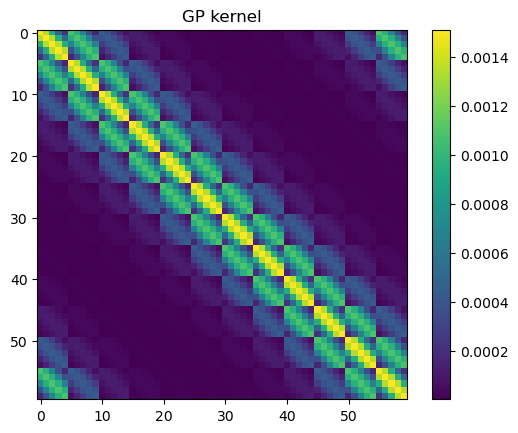

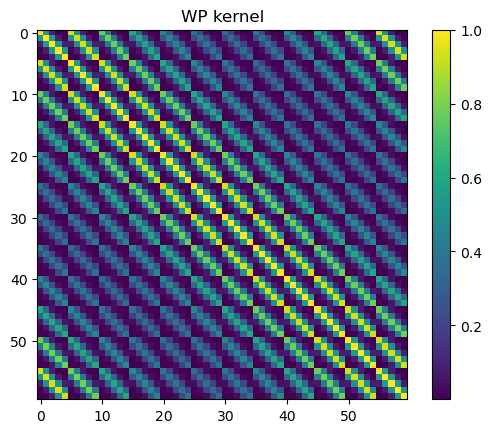

In [126]:
# Define kernels

periodic_gp_angle = lambda a, b: hyperparams["gamma_gp_angle"] * (a == b) + hyperparams["beta_gp_angle"] * jnp.exp(
    -jnp.sin(jnp.pi * jnp.abs(a - b) / PERIOD) ** 2 / hyperparams["lambda_gp_angle"]
)
square_gp_sf = lambda a, b: hyperparams["gamma_gp_sf"] * (a == b) + hyperparams["beta_gp_sf"] * jnp.exp(
    -(a - b) ** 2 / hyperparams["lambda_gp_sf"]
)
kernel_gp = lambda x, y: periodic_gp_angle(x[0], y[0]) * square_gp_sf(x[1], y[1])


gp = models.GaussianProcess(kernel=kernel_gp, N=N)


periodic_wp_angle = lambda a, b: hyperparams["gamma_wp_angle"] * (a == b) + hyperparams["beta_wp_angle"] * jnp.exp(
    -jnp.sin(jnp.pi * jnp.abs(a - b) / PERIOD) ** 2 / hyperparams["lambda_wp_angle"]
)
square_wp_sf = lambda a, b: hyperparams["gamma_wp_sf"] * (a == b) + hyperparams["beta_wp_sf"] * jnp.exp(
    -(a - b) ** 2 / hyperparams["lambda_wp_sf"]
)
kernel_wp = lambda x, y: periodic_wp_angle(x[0], y[0]) * square_wp_sf(x[1], y[1])

optimise_L = True
empirical = jnp.cov((y_tr-y_tr.mean(0)[None]).reshape(K*C,N).T)
V_Picked = empirical + wp_sample_diag * jnp.eye(N)
# V_Picked = empirical + 1e-3 * np.trace(empirical)/N * jnp.eye(N)    

wp = models.WishartLRDProcess(kernel=kernel_wp, P=int(hyperparams["p"]), V=V_Picked, optimize_L=True, diag_scale=DIAG_SCALE)
lik = models.NormalConditionalLikelihood(N)
joint = models.JointGaussianWishartProcess(gp, wp, lik)

plt.imshow(gp.evaluate_kernel(x_tr,x_tr))
plt.title('GP kernel')
plt.colorbar()
plt.show()
plt.imshow(wp.evaluate_kernel(x_tr,x_tr))
plt.title('WP kernel')
plt.colorbar()
plt.show()

# Run

In [127]:
init = {'G':y_tr.mean(0).T[:,None]}
varfam = inference.VariationalNormal(joint.model, init=init)
optimizer = optim.Adam(ADAM_OPT)
key = jax.random.PRNGKey(SEED)
varfam.infer(optimizer, x_tr.squeeze(), y_tr, n_iter=ITERATIONS, key=key, num_particles = NUM_PART)
joint.update_params(varfam.posterior)

100%|██████████| 40000/40000 [09:27<00:00, 70.45it/s, init loss: 106167956.3717, avg. loss [38001-40000]: -77993.4921]


In [128]:
def compute_noise_metrics_all(
    y_response, covariance_fits, mu_test_hat,
    total_k, repeats, seed, small_degree):
    y_response = np.asarray(y_response)
    covariance_fits = np.asarray(covariance_fits)
    mu_test_hat = np.asarray(mu_test_hat)

    if total_k is None:
        kmax = y_response.shape[-1]
    else:
        kmax = total_k

    conditions, neurons = y_response.shape
    c1 = 12
    c2 = 5
    assert conditions == c1 * c2, f"Expected conditions to be {c1*c2}, got {conditions}"

    resp4 = y_response.reshape(c1, c2, neurons)
    substep = small_degree // c1
    resp4_small = mu_test_hat.reshape(small_degree, c2, neurons)
    signal_vectors = resp4[:, np.newaxis, :, :] - resp4[np.newaxis, :, :, :]
    covariance_results = covariance_fits.reshape(c1, c2, neurons, neurons)
    

    dot_prod = np.full((c1, c1 - 1, c2, kmax, repeats), np.nan)
    norm = np.full((c1, c1 - 1, c2, repeats), np.nan)
    top_evals = np.full((c1, c2, kmax, repeats), np.nan)

    dot_prod_small = np.full((c1, c2, kmax, repeats), np.nan)
    norm_small = np.full((c1, c2, repeats), np.nan)


    for r in range(repeats):
        if total_k is not None and total_k < neurons:
            rng = np.random.default_rng(seed + r)
            idx = rng.choice(neurons, total_k, replace=False)
            sig_vec = signal_vectors[:, :, :, idx]
            resp4_small_r = resp4_small[:, :, idx]
            covariance_repeats = np.take(covariance_results, idx, axis=2)
            covariance_repeats = np.take(covariance_repeats, idx, axis=3)
        else:
            sig_vec = signal_vectors
            resp4_small_r = resp4_small
            covariance_repeats = covariance_results

        for sf in range(c2):
            for ia in range(c1):
                covariance = covariance_repeats[ia, sf, :, :]
                try:
                    evals, evecs = np.linalg.eigh(covariance)
                except np.linalg.LinAlgError:
                    continue

                order = np.argsort(evals)[::-1]
                sorted_evals = evals[order]
                sorted_evecs = evecs[:, order]
                top_evals[ia, sf, :, r] = sorted_evals[:kmax]

                others = (ia + np.arange(1, c1)) % c1
                for j, ja in enumerate(others):
                    sv = sig_vec[ia, ja, sf, :]
                    norm[ia, j, sf, r] = np.linalg.norm(sv)
                    for k in range(kmax):
                        pc = sorted_evecs[:, k]
                        dot_prod[ia, j, sf, k, r] = np.dot(sv, pc) ** 2
                
                ia_small = ia*substep
                ja_small = (ia_small+1) % small_degree
                sv_small = resp4_small_r[ia_small, sf, :] - resp4_small_r[ja_small, sf, :]
                norm_small[ia, sf, r] = np.linalg.norm(sv_small)
                for k in range(kmax):
                    pc = sorted_evecs[:, k]
                    dot_prod_small[ia, sf, k, r] = np.dot(sv_small, pc) ** 2

    return {
        "dot_prod": dot_prod,
        "top_evals": top_evals,
        "norm": norm,
        "dot_prod_small": dot_prod_small,
        "norm_small": norm_small,
    }

In [129]:
posterior = models.NormalGaussianWishartPosterior(joint, varfam, X_FULL)
mean_orig_mode, sigma_orig_mode, _= posterior.mode(X_FULL)

In [130]:
small_degree = 36
angles_small = jnp.linspace(0, C1, small_degree, endpoint=False)
X_FULL_SMALL = jnp.column_stack([
    jnp.repeat(angles_small, C2),
    jnp.tile(sfs, small_degree),
])
mu_test_hat, _, _ = posterior.mode(X_FULL_SMALL)
if mu_test_hat.shape[0] != small_degree * C2:
    mu_test_hat =mu_test_hat.transpose()


In [131]:
total_k = None
min_neurons = 60
repeats = 100
seed = 10
mean_orig = np.nanmean(Y_FULL,axis = 0)  # can also be mean_orig_mode 
print("mean_orig shape:", mean_orig.shape)  # Should be (conditions, neurons)
print("mean_orig_mode shape:", mean_orig_mode.shape)  # Should be (conditions, neurons)
print("mu_test_hat shape:", mu_test_hat.shape)  # Should be (small_degree*c2, N_sub)
print("sigma_orig_mode shape:", sigma_orig_mode.shape)  # Should be (conditions, neurons, neurons)
output = compute_noise_metrics_all(mean_orig_mode, sigma_orig_mode, mu_test_hat, total_k, repeats, seed,small_degree)

mean_orig shape: (60, 137)
mean_orig_mode shape: (60, 137)
mu_test_hat shape: (180, 137)
sigma_orig_mode shape: (60, 137, 137)


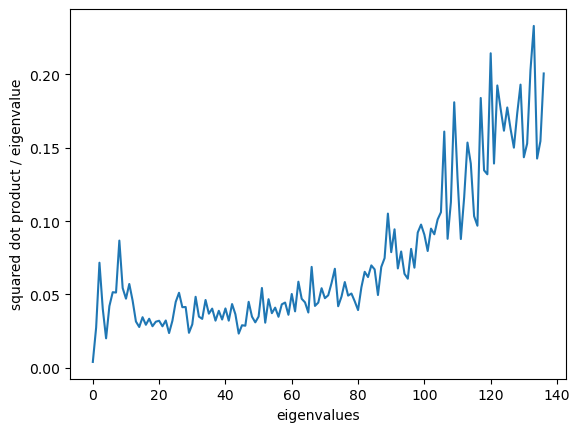

In [135]:
overlaps = output['dot_prod']# Should be (n_angles, n_angles-1, n_sfs, total_k, repeats)
eigs = output['top_evals']# should be (n_angles, n_sfs, total_k, repeats)

dx = 0
average_eigs = np.nanmean(eigs, axis=(0,1,3))
average_overlaps = np.nanmean(overlaps[:,dx,:,:,:], axis=(0,1,3))  
# plt.plot(average_eigs[3:], average_overlaps[3:], marker='o')
# plt.plot(average_overlaps/average_eigs)
plt.xlabel('eigenvalues')
plt.ylabel('squared dot product / eigenvalue')

overlaps_small = output['dot_prod_small']# Should be (n_angles, n_sfs, total_k, repeats)
eigs_small = output['top_evals']# should be (n_angles, n_sfs, total_k, repeats)
average_eigs_small = np.nanmean(eigs_small, axis=(0,1,3))
average_overlaps_small = np.nanmean(overlaps_small, axis=(0,1,3))  
# plt.plot(average_eigs_small[3:], average_overlaps_small[3:], marker='o')
plt.plot(average_overlaps_small/average_eigs_small)
# plt.ylim(0,0.5)


# Analyse results from script

In [2]:
from pathlib import Path
import pickle
import numpy as np

def load_group(prefix, folder="wishart_april"):
    rows = []
    for f in Path(folder).glob(f"{prefix}_*_overlaps_eigs.pkl"):
        with open(f, "rb") as fh:
            d = pickle.load(fh)
        rows.append((d["animal"], f.stem.replace("_overlaps_eigs", ""), d))
    rows.sort(key=lambda x: x[0])

    animal_names = np.array([name for _, name, _ in rows])
    animal_ids   = np.array([aid for aid, _, _ in rows])

    overlaps = np.stack([
        np.asarray(d["overlaps_per_condition"])   # (angles, angles-1, sfs, modes, repeats)
        for _, _, d in rows
    ], axis=0)

    eigs = np.stack([
        np.asarray(d["eigs_per_condition"])       # (angles, sfs, modes, repeats)
        for _, _, d in rows
    ], axis=0)

    overlaps_small = np.stack([
        np.asarray(d["overlaps_small"])           # (angles, sfs, modes, repeats)
        for _, _, d in rows
    ], axis=0)

    return animal_names, animal_ids, overlaps, eigs, overlaps_small


FR_animals, FR_ids, FR_overlaps, FR_eigs, FR_overlaps_small = load_group("FR")
CTR_animals, CTR_ids, CTR_overlaps, CTR_eigs, CTR_overlaps_small = load_group("CTR")

print("FR_overlaps:", FR_overlaps.shape)              # (animals, 12, 11, 5, modes, repeats)
print("FR_eigs:", FR_eigs.shape)                      # (animals, 12, 5, modes, repeats)
print("FR_overlaps_small:", FR_overlaps_small.shape)  # (animals, 12, 5, modes, repeats)

print("CTR_overlaps:", CTR_overlaps.shape)
print("CTR_eigs:", CTR_eigs.shape)
print("CTR_overlaps_small:", CTR_overlaps_small.shape)


FR_overlaps: (8, 12, 11, 5, 56, 100)
FR_eigs: (8, 12, 5, 56, 100)
FR_overlaps_small: (8, 12, 5, 56, 100)
CTR_overlaps: (6, 12, 11, 5, 56, 100)
CTR_eigs: (6, 12, 5, 56, 100)
CTR_overlaps_small: (6, 12, 5, 56, 100)


FR slope: 0.83 (p=0.000), CTR slope: 0.84 (p=0.000)
High eigs - FR slope: 0.84 (p=0.000), CTR slope: 1.06 (p=0.000)
Low eigs - FR slope: 0.83 (p=0.000), CTR slope: 0.82 (p=0.000)


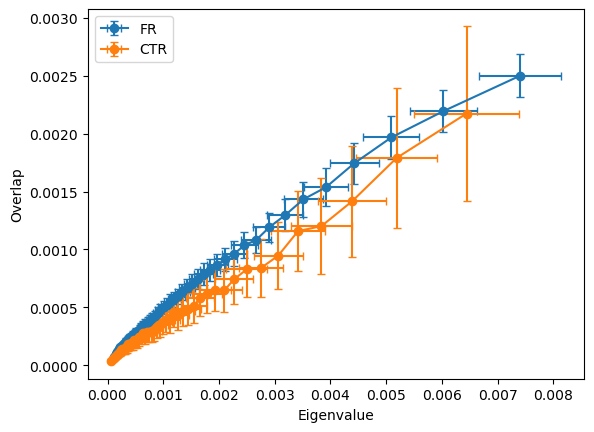

In [40]:
import matplotlib.pyplot as plt
import numpy as np

dx = 0

# keep animal means separate on axis 0
fr_overlap_by_animal = np.nanmean(FR_overlaps[:, :, dx, :, :, :], axis=(1, 2, 4))   # (animals, modes)
fr_eigs_by_animal = np.nanmean(FR_eigs[:, :, dx, :, :], axis=(1, 3))                 # (animals, modes)

ctr_overlap_by_animal = np.nanmean(CTR_overlaps[:, :, dx, :, :, :], axis=(1, 2, 4))  # (animals, modes)
ctr_eigs_by_animal = np.nanmean(CTR_eigs[:, :, dx, :, :], axis=(1, 3))                # (animals, modes)


fr_overlap_small = np.nanmean(FR_overlaps_small[:, :, :, :, :], axis=(1, 2, 4))  # (animals, modes)
fr_overlap_small_mean = np.nanmean(fr_overlap_small, axis=0)  # (modes,)
fr_overlap_small_err = np.nanstd(fr_overlap_small, axis=0) / np.sqrt(fr_overlap_small.shape[0])  # (modes,)

ctr_overlap_small = np.nanmean(CTR_overlaps_small[:, :, :, :, :], axis=(1, 2, 4))  # (animals, modes)
ctr_overlap_small_mean = np.nanmean(ctr_overlap_small, axis=0)  # (modes,)
ctr_overlap_small_err = np.nanstd(ctr_overlap_small, axis=0) / np.sqrt(ctr_overlap_small.shape[0])  # (modes,)


# mean across animals
fr_overlap_mean = np.nanmean(fr_overlap_by_animal, axis=0)
fr_eigs_mean = np.nanmean(fr_eigs_by_animal, axis=0)

ctr_overlap_mean = np.nanmean(ctr_overlap_by_animal, axis=0)
ctr_eigs_mean = np.nanmean(ctr_eigs_by_animal, axis=0)

# error across animals on axis 0
fr_overlap_err = np.nanstd(fr_overlap_by_animal, axis=0) / np.sqrt(fr_overlap_by_animal.shape[0])
fr_eigs_err = np.nanstd(fr_eigs_by_animal, axis=0) / np.sqrt(fr_eigs_by_animal.shape[0])

ctr_overlap_err = np.nanstd(ctr_overlap_by_animal, axis=0) / np.sqrt(ctr_overlap_by_animal.shape[0])
ctr_eigs_err = np.nanstd(ctr_eigs_by_animal, axis=0) / np.sqrt(ctr_eigs_by_animal.shape[0])

plt.errorbar(
    fr_eigs_mean[3:], fr_overlap_mean[3:],
    xerr=fr_eigs_err[3:], yerr=fr_overlap_err[3:],
    marker='o', capsize=3, label='FR'
)

plt.errorbar(
    ctr_eigs_mean[3:], ctr_overlap_mean[3:],
    xerr=ctr_eigs_err[3:], yerr=ctr_overlap_err[3:],
    marker='o', capsize=3, label='CTR'
)

# plt.errorbar(
#     fr_eigs_mean[3:], fr_overlap_small_mean[3:],
#     xerr=fr_eigs_err[3:], yerr=fr_overlap_small_err[3:],
#     marker='o', capsize=3, label='FR small'
# )
# plt.errorbar(
#     ctr_eigs_mean[3:], ctr_overlap_small_mean[3:],
#     xerr=ctr_eigs_err[3:], yerr=ctr_overlap_small_err[3:],
#     marker='o', capsize=3, label='CTR small'
# )



# plt.xscale('log')
# plt.yscale('log')
from scipy.stats import linregress
# check for above and below cutoff
cutoff = 0.002
fr_eigs_high = fr_eigs_mean[3:][fr_eigs_mean[3:] > cutoff]
fr_overlap_high = fr_overlap_mean[3:][fr_eigs_mean[3:] > cutoff]
ctr_eigs_high = ctr_eigs_mean[3:][ctr_eigs_mean[3:] > cutoff]
ctr_overlap_high = ctr_overlap_mean[3:][ctr_eigs_mean[3:] > cutoff]

fr_eigs_low = fr_eigs_mean[3:][fr_eigs_mean[3:] <= cutoff]
fr_overlap_low = fr_overlap_mean[3:][fr_eigs_mean[3:] <= cutoff]
ctr_eigs_low = ctr_eigs_mean[3:][ctr_eigs_mean[3:] <= cutoff]
ctr_overlap_low = ctr_overlap_mean[3:][ctr_eigs_mean[3:] <= cutoff]

slope_fr, intercept_fr, r_value_fr, p_value_fr, std_err_fr = linregress(np.log(fr_eigs_mean[3:]), np.log(fr_overlap_mean[3:]))
slope_ctr, intercept_ctr, r_value_ctr, p_value_ctr, std_err_ctr = linregress(np.log(ctr_eigs_mean[3:]), np.log(ctr_overlap_mean[3:]))
print(f"FR slope: {slope_fr:.2f} (p={p_value_fr:.3f}), CTR slope: {slope_ctr:.2f} (p={p_value_ctr:.3f})")


slope_fr_high, intercept_fr_high, r_value_fr_high, p_value_fr_high, std_err_fr_high = linregress(np.log(fr_eigs_high), np.log(fr_overlap_high))
slope_ctr_high, intercept_ctr_high, r_value_ctr_high, p_value_ctr_high, std_err_ctr_high = linregress(np.log(ctr_eigs_high), np.log(ctr_overlap_high))
print(f"High eigs - FR slope: {slope_fr_high:.2f} (p={p_value_fr_high:.3f}), CTR slope: {slope_ctr_high:.2f} (p={p_value_ctr_high:.3f})")
slope_fr_low, intercept_fr_low, r_value_fr_low, p_value_fr_low, std_err_fr_low = linregress(np.log(fr_eigs_low), np.log(fr_overlap_low))
slope_ctr_low, intercept_ctr_low, r_value_ctr_low, p_value_ctr_low, std_err_ctr_low = linregress(np.log(ctr_eigs_low), np.log(ctr_overlap_low))
print(f"Low eigs - FR slope: {slope_fr_low:.2f} (p={p_value_fr_low:.3f}), CTR slope: {slope_ctr_low:.2f} (p={p_value_ctr_low:.3f})")



plt.xlabel("Eigenvalue")
plt.ylabel("Overlap")
plt.legend()
plt.show()


FR  SNR = 0.0005357 ± 5.989e-05 SEM
CTR SNR = 0.0003898 ± 0.0001979 SEM


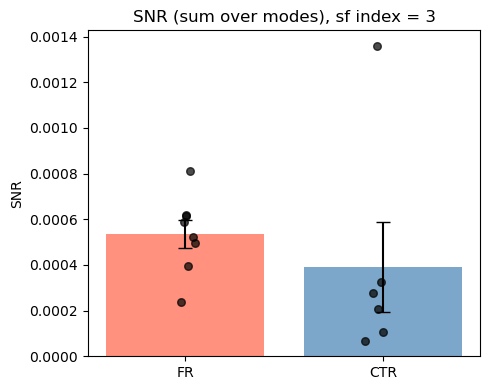

In [30]:
import numpy as np
import matplotlib.pyplot as plt

dx = 3  # choose sf index

# SNR per animal, per angle-pair, per repeat:
# sum over modes of overlap * eigenvalue
FR_snr = np.nansum(FR_overlaps[:, :, dx, :, :, :] * FR_eigs[:, :, dx, None, :, :], axis=3)
CTR_snr = np.nansum(CTR_overlaps[:, :, dx, :, :, :] * CTR_eigs[:, :, dx, None, :, :], axis=3)
# shapes: (animals, angles, angles-1, repeats)

# Average within each animal, keeping animal axis 0 for errors
FR_snr_by_animal = np.nanmean(FR_snr, axis=(1, 2, 3))   # (animals,)
CTR_snr_by_animal = np.nanmean(CTR_snr, axis=(1, 2, 3)) # (animals,)

# Group means and SEM across animals
FR_snr_mean = np.nanmean(FR_snr_by_animal)
CTR_snr_mean = np.nanmean(CTR_snr_by_animal)

FR_snr_sem = np.nanstd(FR_snr_by_animal, ddof=1) / np.sqrt(len(FR_snr_by_animal))
CTR_snr_sem = np.nanstd(CTR_snr_by_animal, ddof=1) / np.sqrt(len(CTR_snr_by_animal))

print(f"FR  SNR = {FR_snr_mean:.4g} ± {FR_snr_sem:.4g} SEM")
print(f"CTR SNR = {CTR_snr_mean:.4g} ± {CTR_snr_sem:.4g} SEM")

# Nice plot
x = np.array([0, 1])
means = np.array([FR_snr_mean, CTR_snr_mean])
sems = np.array([FR_snr_sem, CTR_snr_sem])

plt.figure(figsize=(5, 4))
plt.bar(x, means, color=["tomato", "steelblue"], alpha=0.7)
plt.errorbar(x, means, yerr=sems, fmt="none", ecolor="black", capsize=5, lw=1.5)

# show individual animals too
rng = np.random.default_rng(0)
plt.scatter(np.full_like(FR_snr_by_animal, x[0], dtype=float) + rng.normal(0, 0.04, len(FR_snr_by_animal)),
            FR_snr_by_animal, color="black", s=30, alpha=0.7)
plt.scatter(np.full_like(CTR_snr_by_animal, x[1], dtype=float) + rng.normal(0, 0.04, len(CTR_snr_by_animal)),
            CTR_snr_by_animal, color="black", s=30, alpha=0.7)

plt.xticks(x, ["FR", "CTR"])
plt.ylabel("SNR")
plt.title(f"SNR (sum over modes), sf index = {dx}")
plt.tight_layout()
plt.show()


Slope: 0.11 (p=0.136)


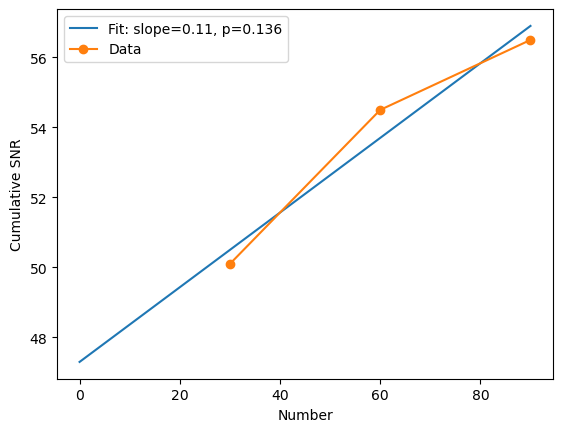

In [ ]:
x1 = [30,60,90]
cumulative_snr = [50.1,54.5,56.5]
# fit x1 and cumulative_snr to a line and plot 
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(x1, cumulative_snr)
print(f"Slope: {slope:.2f} (p={p_value:.3f})")
xx = np.linspace(0, max(x1), 100)
plt.plot(xx, intercept + slope * xx, label=f"Fit: slope={slope:.2f}, p={p_value:.3f}")
plt.plot(x1, cumulative_snr, marker='o', label='Data')
plt.xlabel("Number")
plt.ylabel("Cumulative SNR")
plt.legend()
plt.show()

x2 = [30,20,10,7.5,5,0]
behavioural_score_fr = [80.5,72.5,68.5,63.5,56.5,50]
behavioural_score_ctr = [80,72.5,69,55.5,52,50]


# No Here we should actually try and fit the decision time from the behavioural data 

# Analyse

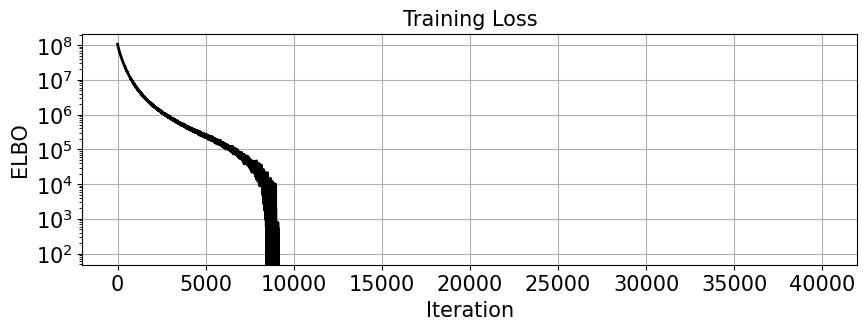

In [136]:
# %% Visualization
visualizations.plot_loss(
    [varfam.losses],xlabel='Iteration',ylabel='ELBO',titlestr='Training Loss',colors=['k'],
)
# plt.plot(varfam.losses)
# plt.ylim(top=100)
# plt.yscale('log')
# plt.ylim(-1.5e5,20000)
# plt.xlim(20000,ITERATIONS)

In [137]:
NMC = 100
posterior = models.NormalGaussianWishartPosterior(joint, varfam, x_tr)

# Held-out log-likelihood
def one_draw(rng):
    with numpyro.handlers.seed(rng_seed=rng):
        mu, Sigma, _ = posterior.sample(x_test)
    return lik.log_prob(y_test, mu, Sigma).mean()

mc_keys = jax.random.split(jax.random.PRNGKey(SEED), NMC)
print("Held-out mean log-lik:", float(jax.vmap(one_draw)(mc_keys).mean()))

Held-out mean log-lik: 168.18486754690426


In [ ]:
from numpyro import distributions as dist

NMC = 100
posterior = models.NormalGaussianWishartPosterior(joint, varfam, x_tr)
# # Held-out log-likelihood
# def one_draw(rng):
#     with numpyro.handlers.seed(rng_seed=rng):
#         mu, Sigma, _ = posterior.sample(x_test)
#     return lik.log_prob(y_test, mu, Sigma).mean()

# mc_keys = jax.random.split(jax.random.PRNGKey(SEED), NMC)
# print("Held-out mean log-lik:", float(jax.vmap(one_draw)(mc_keys).mean()))

with numpyro.handlers.seed(rng_seed=jax.random.PRNGKey(SEED)):
    lp = posterior.log_prob(x_test, y_test)
print(lp.shape)
plt.boxplot(lp)

# Empirical held out log likeilihood
def empirical_loglik_per_condition(y_train, y_test, jitter=1e-6):
    """
    y_train: (K_train, C, N)
    y_test:  (K_test,  C, N)
    Returns:
      lp_test: (K_test, C) log-likelihood for each held-out trial/condition
      per_cond_mean: (C,) mean over trials for each condition
    """
    Kt, C, N = y_train.shape
    Kte = y_test.shape[0]

    mu = y_train.mean(axis=0)  # (C, N)
    sigma = np.zeros((C, N, N))
    for c in range(C):
        cov = np.cov(y_train[:, c, :], rowvar=False)
        sigma[c] = cov + jitter * np.eye(N)

    # compute loglik for each condition
    lp = []
    for c in range(C):
        mvn = dist.MultivariateNormal(loc=jnp.asarray(mu[c]), covariance_matrix=jnp.asarray(sigma[c]))
        lp_c = mvn.log_prob(jnp.asarray(y_test[:, c, :]))  # (K_test,)
        lp.append(lp_c)
    lp = jnp.stack(lp, axis=1)  # (K_test, C)

    return lp, lp.mean(axis=0)
lp_emp, emp_per_cond = empirical_loglik_per_condition(y_tr, y_test, jitter=1e-6)


In [ ]:
# print(lp_emp.shape)
plt.boxplot(lp_emp)

In [ ]:
per_trial = lp.mean(axis=1)      # average over conditions
per_cond  = lp.mean(axis=0)      # average over trials
global_mean = lp.mean()          # single scalar (can be big)

print("Global mean log-lik:", global_mean)

In [ ]:
import jax.numpy as jnp
import evaluation
import visualizations
import numpyro

# posterior samples on training conditions
posterior = models.NormalGaussianWishartPosterior(joint, varfam, x_tr)
with numpyro.handlers.seed(rng_seed=SEED):
    mu_hat, sigma_hat, _ = posterior.mode(x_tr)  # mu_hat: C x N, sigma_hat: C x N x N

# held-out trials (same conditions)
y_trials = y_te["x"]  # K_test x C_train x N
mu_emp = y_tr.mean(0)  # C x N
# empirical cov from held-out trials
sigma_emp_trials = evaluation.compare(y_trials)["empirical"]  # N x N x C

# baselines from training trials
compared = evaluation.compare(y_tr)
compared["wishart"] = sigma_hat.transpose(1, 2, 0)

# grand empirical = pooled residual covariance (condition-mean removed)
y_centered = y_tr - y_tr.mean(0, keepdims=True)               # K x C x N
grand = jnp.cov(y_centered.reshape(-1, y_tr.shape[-1]).T)     # N x N
compared["grand-empirical"] = jnp.repeat(grand[:, :, None], y_tr.shape[1], axis=2)



# covariance error (operator + Frobenius)
perf_op = evaluation.evaluate(compared, sigma_emp_trials, ord=2)
perf_fro = evaluation.evaluate(compared, sigma_emp_trials, ord="fro")
visualizations.plot_box(perf_op, titlestr="Cov error (op norm vs held-out trials)")
visualizations.plot_box(perf_fro, titlestr="Cov error (Fro norm vs held-out trials)")

# mean MSE vs held-out trials
mse = lambda a, b: jnp.sqrt(((a - b) ** 2).sum(-1))
mu_emp_trials = y_trials.mean(0)
perf_mean = {
    "wishart": mse(mu_emp, mu_emp_trials),
    "empirical": mse(y_tr.mean(0), mu_emp_trials),
}
visualizations.plot_box(perf_mean, titlestr="Mean MSE vs held-out trials")

# held-out log-likelihood
lpp = {}
mu_emp = y_tr.mean(0)
for key in compared:
    lpp[key] = lik.log_prob(y_trials, mu_emp, compared[key].transpose(2, 0, 1)).flatten()
lpp["wishart"] = lik.log_prob(y_trials, mu_emp, sigma_hat).flatten()
visualizations.plot_box(lpp, titlestr="Held-out log-lik")


In [ ]:
# Create the posterior distribution instance and sample from it in train and test conditions and plot it
posterior = models.NormalGaussianWishartPosterior(joint,varfam,x_tr)
with numpyro.handlers.seed(rng_seed=SEED):
    mu_hat, sigma_hat, F_hat = posterior.mode(x_tr)
    # mu_prime, sigma_prime = posterior.derivative(x_tr)

with numpyro.handlers.seed(rng_seed=SEED):
    mu_test_hat, sigma_test_hat, F_test_hat = posterior.sample(x_test)
    # mu_test_prime, sigma_test_prime = posterior.derivative(x_test)

# visualizations.visualize_pc(
#     mu_hat[:,None],sigma_hat,
#     pc=y_tr.reshape(y_tr.shape[0]*y_tr.shape[1],-1),
#     std = .5
# )


visualizations.visualize_pc(
    mu_emp[:, None],
    sigma_hat,
    pc=y_tr.reshape(y_tr.shape[0] * y_tr.shape[1], -1),
    std=0.5,
)

In [ ]:
# EMPIRICAL ANALYSIS
import pandas as pd
empirical_mu = jnp.nanmean(y_tr,axis=0)
print(empirical_mu.shape)
# empirical_cov =jnp.cov(TEST_RESPONSE,axis=0)
empirical_sigma = jnp.zeros((C1, N, N))
for i in range(C1):
    dat = y_tr[:,i,:] # Shape K x N
    df = pd.DataFrame(dat)
    covariances = df.cov().to_numpy()
    covariances += np.eye(N) * 1e-12
    empirical_sigma = empirical_sigma.at[i].set(covariances)
visualizations.visualize_pc(
    empirical_mu[:,None],empirical_sigma,pc=y_tr.reshape(y_tr.shape[0]*y_tr.shape[1],-1),
    std = 0.5
)

In [ ]:
print(mu_hat.shape)
print(x_tr.shape)
print(x_tr[0,:])
# indices in xfull where first index is -1
indices = jnp.where(x_tr[:,1] == (np.log2(0.02)))[0]
print(indices)
mu_ring = mu_emp[indices,:]
sigma_ring = sigma_hat[indices,:,:]
Y_RING = y_tr[:,indices,:]#.reshape(K*C1,-1)
print(Y_RING.shape, mu_ring.shape, sigma_ring.shape)

visualizations.visualize_pc(
    mu_ring[:,None],
    sigma_ring,
    pc=Y_RING.reshape(K*C1,-1),
    title_str="Averaged over C2 (ring over C1, jittered predictive)",
    dotsize=12,
    std = 0.5
)

In [ ]:
# EMPIRICAL ANALYSIS
import pandas as pd
empirical_mu = jnp.nanmean(Y_RING,axis=0)
print(empirical_mu.shape)
# empirical_cov =jnp.cov(TEST_RESPONSE,axis=0)
empirical_sigma = jnp.zeros((C1, N, N))
for i in range(C1):
    dat = Y_RING[:,i,:] # Shape K x N
    df = pd.DataFrame(dat)
    covariances = df.cov().to_numpy()
    covariances += np.eye(N) * 1e-12
    empirical_sigma = empirical_sigma.at[i].set(covariances)
visualizations.visualize_pc(
    empirical_mu[:,None],empirical_sigma,pc=Y_RING.reshape(Y_RING.shape[0]*Y_RING.shape[1],-1)
)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse

# Inputs
y_train = np.asarray(y_tr)
y_test_trials = np.asarray(y_te["x"] if isinstance(y_te, dict) else y_te)
sigma_hat = np.asarray(sigma_hat)

cond_ids = np.random.choice(y_train.shape[1], size=2, replace=False) #[0, 24]  # adjust (Condition 1 and 25)
n_std = 2.0

# PCA on all train+test points in training conditions
# all_pts = np.concatenate([y_train, y_test_trials], axis=0).reshape(-1, y_train.shape[-1])
# pca = PCA(n_components=2).fit(all_pts)


train_res = y_train - y_train.mean(0, keepdims=True)
test_res  = y_test_trials - y_train.mean(0, keepdims=True)
all_res   = np.concatenate([train_res, test_res], axis=0).reshape(-1, N)
pca = PCA(n_components=2).fit(all_res)
# mu_cond = y_train.mean(0)                 # C x N
# pca = PCA(n_components=2).fit(mu_cond)

def proj(x):
    return pca.transform(x)

def cov_to_pc(cov):
    return pca.components_ @ cov @ pca.components_.T

def add_cov_ellipse(mu, cov, ax, n_std=2.0, **kwargs):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(vals)
    ell = Ellipse(mu, width, height, angle=angle, fill=False, **kwargs)
    ax.add_patch(ell)

# Grand empirical covariance (pooled residuals, condition-mean removed)
y_centered = y_train - y_train.mean(0, keepdims=True)
grand_cov = np.cov(y_centered.reshape(-1, y_train.shape[-1]), rowvar=False)

colors = {
    "empirical": "#3fcf5e",
    "grand": "#7566fa",   # tweak to match panel B
    "wishart": "#000000", # tweak to match panel B
}

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
for ax, cond in zip(axes, cond_ids):
    train_pts = proj(y_train[:, cond, :])
    test_pts = proj(y_test_trials[:, cond, :])

    ax.scatter(train_pts[:, 0], train_pts[:, 1], s=12, c="k", label="train" if cond == cond_ids[0] else None)
    ax.scatter(test_pts[:, 0], test_pts[:, 1], s=12, c="r", label="test" if cond == cond_ids[0] else None)
    
    mu_emp = y_train[:, cond, :].mean(0)
    mu_pc = proj(mu_emp[None, :])[0]
    ax.scatter(mu_pc[0], mu_pc[1], s=100, c="gold", marker="*", label="mean" if cond == cond_ids[0] else None)

    cov_emp = np.cov(y_train[:, cond, :], rowvar=False)
    cov_wish = sigma_hat[cond]

    add_cov_ellipse(mu_pc, cov_to_pc(cov_emp), ax, n_std=n_std, color=colors["empirical"], lw=2)
    add_cov_ellipse(mu_pc, cov_to_pc(grand_cov), ax, n_std=n_std, color=colors["grand"], lw=2)
    add_cov_ellipse(mu_pc, cov_to_pc(cov_wish), ax, n_std=n_std, color=colors["wishart"], lw=2)

    ax.set_title(f"Condition {cond + 1}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_aspect("equal", adjustable="box")
handles = [plt.Line2D([0], [0], color=colors[k], lw=2) for k in colors]
labels = ["empirical", "grand-empirical", "wishart"]
axes[1].legend(handles, labels, frameon=False, loc="lower right")
# axes[0].legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.covariance import EmpiricalCovariance, LedoitWolf
from matplotlib.patches import Ellipse

# -------------------------
# Inputs
# -------------------------
y_train = np.asarray(y_tr)                                   # K_train x C x N
y_test_trials = np.asarray(y_te["x"] if isinstance(y_te, dict) else y_te)  # K_test x C x N

# deterministic Wishart estimate (avoid one random posterior sample for plotting)
posterior = models.NormalGaussianWishartPosterior(joint, varfam, x_tr)
mu_mode, sigma_mode, _ = posterior.mode(x_tr)                # C x N, C x N x N
sigma_wish_all = np.asarray(sigma_mode)

Ktr, C, N = y_train.shape
cond_ids = np.random.choice(C, size=2, replace=False)        # random conditions each run
n_std = 2.0

# -------------------------
# PCA basis (paper-style PC space)
# -------------------------
# Use condition means, not residual cloud
mu_cond = y_train.mean(0)                                    # C x N
pca = PCA(n_components=2).fit(mu_cond)
W = pca.components_                                           # 2 x N

def proj(x):
    return pca.transform(x)

def cov_to_pc(cov):
    c2 = W @ cov @ W.T
    c2 = 0.5 * (c2 + c2.T)                                   # symmetrize
    # small PSD guard for numerical noise
    vals = np.linalg.eigvalsh(c2)
    if vals.min() < 1e-12:
        c2 = c2 + np.eye(2) * (1e-12 - vals.min())
    return c2

def add_cov_ellipse(mu, cov, ax, n_std=2.0, **kwargs):
    vals, vecs = np.linalg.eigh(cov)
    vals = np.clip(vals, 1e-12, None)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(vals)
    ell = Ellipse(mu, width, height, angle=angle, fill=False, **kwargs)
    ax.add_patch(ell)

# -------------------------
# Covariance estimators (exact definitions)
# -------------------------
# Empirical per condition (Eq. 1)
cov_emp_all = np.stack(
    [EmpiricalCovariance().fit(y_train[:, c, :]).covariance_ for c in range(C)],
    axis=0
)  # C x N x N

# Grand empirical (Eq. 2): average over condition empirical covariances
grand_cov = cov_emp_all.mean(axis=0)                         # N x N

# Optional Ledoit-Wolf per condition (for full Fig4c-style legend)
cov_lw_all = np.stack(
    [LedoitWolf().fit(y_train[:, c, :]).covariance_ for c in range(C)],
    axis=0
)

colors = {
    "lw": "#6cc8f0",
    "empirical": "#3fcf5e",
    "grand": "#7566fa",
    "wishart": "#000000",
}

# -------------------------
# Plot
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)

for ax, cond in zip(axes, cond_ids):
    train_pts = proj(y_train[:, cond, :])
    test_pts  = proj(y_test_trials[:, cond, :])

    ax.scatter(train_pts[:, 0], train_pts[:, 1], s=12, c="k")
    ax.scatter(test_pts[:, 0],  test_pts[:, 1],  s=12, c="r")

    # common center for all ellipses (empirical condition mean)
    mu_emp = y_train[:, cond, :].mean(0)
    mu_pc = proj(mu_emp[None, :])[0]
    ax.scatter(mu_pc[0], mu_pc[1], s=100, c="gold", marker="*")

    add_cov_ellipse(mu_pc, cov_to_pc(cov_lw_all[cond]),   ax, n_std=n_std, color=colors["lw"], lw=2)
    add_cov_ellipse(mu_pc, cov_to_pc(cov_emp_all[cond]),  ax, n_std=n_std, color=colors["empirical"], lw=2)
    add_cov_ellipse(mu_pc, cov_to_pc(grand_cov),          ax, n_std=n_std, color=colors["grand"], lw=2)
    add_cov_ellipse(mu_pc, cov_to_pc(sigma_wish_all[cond]), ax, n_std=n_std, color=colors["wishart"], lw=2)

    # diagnostics: empirical circularity in PC space
    ev = np.linalg.eigvalsh(cov_to_pc(cov_emp_all[cond]))
    print(f"Condition {cond+1}: empirical anisotropy ratio λmax/λmin = {ev.max()/ev.min():.3f}")

    ax.set_title(f"Condition {cond + 1}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_aspect("equal", adjustable="box")

handles = [plt.Line2D([0], [0], color=colors[k], lw=2) for k in ["lw","empirical","grand","wishart"]]
labels = ["LW", "Empirical", "Grand Empirical", "Wishart"]
axes[1].legend(handles, labels, frameon=False, loc="lower right")
plt.tight_layout()
plt.show()


In [ ]:
for cond in cond_ids:
    e_emp = np.linalg.eigvalsh(cov_to_pc(cov_emp_all[cond]))
    e_grd = np.linalg.eigvalsh(cov_to_pc(grand_cov))
    e_wsh = np.linalg.eigvalsh(cov_to_pc(sigma_hat[cond]))
    print(f"cond {cond+1} | emp anis={e_emp.max()/e_emp.min():.3f} "
          f"| grand anis={e_grd.max()/e_grd.min():.3f} "
          f"| wish anis={e_wsh.max()/e_wsh.min():.3f}")


In [ ]:

y_trials = y_te["x"]  # K_test x C_train x N
mu_emp = y_tr.mean(0)  # C x N

lpp = {}
for key in compared:
    if key == "empirical":
        continue
    lpp[key] = lik.log_prob(y_trials, mu_emp, compared[key].transpose(2,0,1)).flatten()

# Wishart covariance-only
lpp["wishart_cov_only"] = lik.log_prob(y_trials, mu_emp, sigma_hat).flatten()

# Wishart full predictive (as you currently do)

lpp["wishart"] = lik.log_prob(y_trials, mu_emp, sigma_hat).flatten()

visualizations.plot_box(lpp, titlestr="Held-out log-lik with different means")

In [ ]:
import jax
import jax.numpy as jnp
import numpy as np
import numpyro
import evaluation
import visualizations

def posterior_predictive_lp(posterior, x_eval, y_eval, vi_samples=50, gp_samples=1, seed=1):
    with numpyro.handlers.seed(rng_seed=jax.random.PRNGKey(seed)):
        lp = posterior.log_prob(x_eval, y_eval, vi_samples=vi_samples, gp_samples=gp_samples)
    return jnp.asarray(lp)  # K_test x C

posterior = models.NormalGaussianWishartPosterior(joint, varfam, x_tr)
y_trials = y_te["x"]
mu_emp = y_tr.mean(0)

# baselines from train
sigma_emp = evaluation.compare(y_tr)["empirical"].transpose(2, 0, 1)  # C x N x N
y_centered = y_tr - y_tr.mean(0, keepdims=True)
grand = jnp.cov(y_centered.reshape(-1, y_tr.shape[-1]).T)
sigma_grand = jnp.repeat(grand[None, :, :], y_tr.shape[1], axis=0)

# deterministic Wishart covariance-only baseline
_, sigma_mode, _ = posterior.mode(x_tr)

lpp = {}
lpp["empirical_cov_only"] = lik.log_prob(y_trials, mu_emp, sigma_emp).flatten()
lpp["grand_cov_only"] = lik.log_prob(y_trials, mu_emp, sigma_grand).flatten()
lpp["wishart_cov_only"] = lik.log_prob(y_trials, mu_emp, sigma_mode).flatten()

# full posterior predictive (same estimator family as search script)

for k, v in lpp.items():
    print(k, float(jnp.mean(v)))

visualizations.plot_box(lpp, titlestr="Held-out log-lik (consistent estimator)")


# Hyperparam Searching Results

In [ ]:
import json

files = [
    # "outputs/hyperparam_cv_results_feb_gonz_further.json",  # change
    # "outputs/hyperparam_cv_results_lecona_feb_further.json",  # change
    # "outputs/hyperparam_cv_results_feb_12_lec.json",  # change
    # "outputs/hyperparam_cv_results_feb_12.json",  #
    "outputs/hyperparam_cv_results_feb_17.json",
    "outputs/hyperparam_cv_results_feb_17_gonz.json",
]


entries = []
for f in files:
    with open(f, "r") as fh:
        data = json.load(fh)
    entries.extend(data["lambda_sweep"]["entries"])

# Best overall (by mean)
best = max(entries, key=lambda e: e["mean"])

print("Best overall mean:", best["mean"])
print("Best lambdas:", best["lambdas"])
print("Best p:", best["p"])

# (optional) top 5
top5 = sorted(entries, key=lambda e: e["mean"], reverse=True)[:5]
print("\nTop 5:")
for i, e in enumerate(top5, 1):
    print(f"{i}) mean={e['mean']:.4f}, p={e['p']}, lambdas={e['lambdas']}")


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt


entries = []
for f in files:
    with open(f, "r") as fh:
        data = json.load(fh)
    entries.extend(data["lambda_sweep"]["entries"])

# best overall
best = max(entries, key=lambda e: e["mean"])

lambda_keys = ["gp_angle", "gp_sf", "wp_angle", "wp_sf"]
ps = sorted({int(e["p"]) for e in entries})

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.ravel()
#keep only p=0 
ps = [0,1,2,3,4]
for ax, key in zip(axes, lambda_keys):
    for p in ps:
        xs = [e["lambdas"][key] for e in entries if int(e["p"]) == p]
        ys = [e["mean"] for e in entries if int(e["p"]) == p]
        ax.scatter(xs, ys, alpha=0.4, s=20, label=f"p={p}")
    ax.scatter([best["lambdas"][key]], [best["mean"]], color="red", s=10, label="best overall")
    # ax.set_xscale("log")  # log x helps see range
    ax.set_xlabel(key)
    ax.set_ylabel("mean log-likelihood")
    ax.set_ylim(140,None)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Random search results: mean log-likelihood vs each lambda")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

lambda_keys = ["gp_angle", "gp_sf", "wp_angle", "wp_sf"]
ps = [0]  # or [0] if you want only p=0

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.ravel()

for ax, key in zip(axes, lambda_keys):
    for p in ps:
        xs, ys, yerr = [], [], []
        for e in entries:
            if int(e["p"]) != p:
                continue
            xs.append(e["lambdas"][key])
            ys.append(e["mean"])
            # std across folds using fold score_mean
            fold_means = [f["score_mean"] for f in e["folds"]]
            yerr.append(np.std(fold_means)/np.sqrt(len(fold_means)))  # SEM

        ax.errorbar(xs, ys, yerr=yerr, fmt="o", alpha=0.2, label=f"p={p}")

    ax.scatter([best["lambdas"][key]], [best["mean"]],
               color="red", s=40, label="best overall")

    ax.set_xlabel(key)
    ax.set_ylabel("mean log-likelihood")
    ax.set_ylim(50, 200)
    ax.grid(True, alpha=0.3)
    # ax.set_xscale('log')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Random search results: mean log-likelihood vs each lambda")
plt.tight_layout()
plt.show()


In [ ]:
entries = []
for f in files:
    with open(f, "r") as fh:
        data = json.load(fh)
    entries.extend(data["lambda_sweep"]["entries"])

# ---- decision rule: top 10% by mean ----
means = np.array([e["mean"] for e in entries])
cutoff = np.percentile(means, 90)
top_entries = [e for e in entries if e["mean"] >= cutoff]

print(f"Top-10% cutoff: {cutoff:.3f}, kept {len(top_entries)} / {len(entries)}")

# ---- helper: std across conditions ----
# We compute per-fold std across conditions:
#   lp: K_test x C
#   per_cond = mean over trials -> shape (C,)
#   std_cond = std(per_cond)
# Then average across folds for the entry.
def std_across_conditions(entry):
    stds = []
    for f in entry["folds"]:
        lp = f.get("score_lp", None)
        if lp is None:
            continue
        lp = np.asarray(lp)
        if lp.ndim != 2:
            continue
        per_cond = lp.mean(axis=0)
        stds.append(per_cond.std())
    return float(np.mean(stds)) if stds else np.nan

# ---- helper: std across folds (means) ----
def std_across_folds(entry):
    fold_means = [f["score_mean"] for f in entry["folds"]]
    return float(np.std(fold_means)) if fold_means else np.nan

# precompute stats
for e in top_entries:
    e["std_conditions"] = std_across_conditions(e)
    e["std_folds"] = std_across_folds(e)

lambda_keys = ["gp_angle", "gp_sf", "wp_angle", "wp_sf"]
ps = sorted({int(e["p"]) for e in entries})

# ---- plot 1: std across conditions (top 10%) ----
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.ravel()

for ax, key in zip(axes, lambda_keys):
    for p in ps:
        xs = [e["lambdas"][key] for e in top_entries if int(e["p"]) == p]
        ys = [e["std_conditions"] for e in top_entries if int(e["p"]) == p]
        ax.scatter(xs, ys, alpha=0.6, s=30, label=f"p={p}")
    # ax.set_xscale("log")
    ax.set_xlabel(key)
    ax.set_ylabel("std across conditions")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Top 10% mean: std across conditions")
plt.tight_layout()
plt.show()

# ---- plot 2: std across folds (top 10%) ----
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.ravel()

for ax, key in zip(axes, lambda_keys):
    for p in ps:
        xs = [e["lambdas"][key] for e in top_entries if int(e["p"]) == p]
        ys = [e["std_folds"] for e in top_entries if int(e["p"]) == p]
        ax.scatter(xs, ys, alpha=0.6, s=30, label=f"p={p}")
    # ax.set_xscale("log")
    ax.set_xlabel(key)
    ax.set_ylabel("std across folds (mean)")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Top 10% mean: std across folds")
plt.tight_layout()
plt.show()

#print of the top entries print the top 5 smallest std across conditions among the top 10% mean entries
top_entries_sorted = sorted(top_entries, key=lambda e: e["std_conditions"])
print("\nTop 5 smallest std across conditions (among top 10% mean):")
for i, e in enumerate(top_entries_sorted[:10], 1):
    print(f"{i}) mean={e['mean']:.4f}, std_cond={e['std_conditions']:.4f}, p={e['p']}, lambdas={e['lambdas']}")

# print the top 5 smallest std across folds among the top 10% mean entries
top_entries_sorted_folds = sorted(top_entries, key=lambda e: e["std_folds"])
print("\nTop 5 smallest std across folds (among top 10% mean):")
for i, e in enumerate(top_entries_sorted_folds[:10], 1):
    print(f"{i}) mean={e['mean']:.4f}, std_folds={e['std_folds']:.4f}, p={e['p']}, lambdas={e['lambdas']}")



# Smallest condition std for entries with fold std<1
filtered = [e for e in top_entries if e["std_folds"] < 1.0]
filtered_sorted = sorted(filtered, key=lambda e: e["std_conditions"])
print("\nTop 5 smallest std across conditions (fold std < 1):")
for i, e in enumerate(filtered_sorted[:10], 1):
    print(f"{i}) mean={e['mean']:.4f}, std_cond={e['std_conditions']:.4f}, std_folds={e['std_folds']:.4f}, p={e['p']}, lambdas={e['lambdas']}")

# Compare covariance to emprircal

In [ ]:
evals_store = np.zeros((12,50))
for iangle in range(12):
    cov_matrix = sigma_ring[iangle,:,:]
    eval, evec = np.linalg.eigh(cov_matrix)
    non_zero_evals = eval[::-1]
    evals_store[iangle,:] = non_zero_evals[:50]
    # plt.scatter(np.arange(len(non_zero_evals)), non_zero_evals)
    # plt.title(f'Angle {iangle}')
    # plt.show()
average_evals = np.mean(evals_store, axis=0)
plt.scatter(np.arange(len(average_evals)), average_evals)





In [ ]:
raw_evals_store = np.zeros((12,50))
for iangle in range(12):
    test = Y_RING[:,iangle,:]  # shape (K, N)
    covariance_matrix = np.cov(test, rowvar=False)  # shape (N, N)
    eval, evec = np.linalg.eigh(covariance_matrix)
    non_zero_evals = eval[::-1]
    raw_evals_store[iangle,:] = non_zero_evals[:50]
average_raw_evals = np.mean(raw_evals_store, axis=0)#[1:]
y_error_raw = np.std(raw_evals_store, axis=0) #/ np.sqrt(raw_evals_store.shape[0])
y_error_model = np.std(evals_store, axis=0)# / np.sqrt(evals_store.shape[0])
plt.scatter(np.arange(len(average_raw_evals)), average_raw_evals, color = 'green')
plt.fill_between(np.arange(len(average_raw_evals)), average_raw_evals - y_error_raw, average_raw_evals + y_error_raw, alpha=0.5, label='Raw Evals Std Dev', color = 'green')
plt.scatter(np.arange(len(average_evals)), average_evals, color = 'black')
plt.fill_between(np.arange(len(average_evals)), average_evals - y_error_model, average_evals + y_error_model, alpha=0.5, label='Model Evals Std Dev', color = 'black')
# plt.ylim(0,0.25)
plt.xlim(0,10)


In [ ]:
# overlaps between top empirical and model eigenvectors for each angle
raw_evals_store = np.zeros((12,50))
for iangle in range(12):
    test = Y_RING[:,iangle,:]  # shape (K, N)
    covariance_matrix_data = np.cov(test, rowvar=False)  # shape (N, N)
    covariance_matrix_model = sigma_ring[iangle,:,:]
    _,evec_data = np.linalg.eigh(covariance_matrix_data)
    _,evec_model = np.linalg.eigh(covariance_matrix_model)

    overlap = np.dot(evec_data[:,-1], evec_model[:,-1])**2
    plt.scatter(iangle, overlap)


In [ ]:
# Overlap between top eigenvector of close angle
# Should see V or trend over angles if FIXED = 0 if iangle then should see nothing?

raw_evals_store = np.zeros((12,50))
for iangle in range(12):
    FIXED = 0
    covariance_matrix_data1 = np.cov(Y_RING[:,FIXED,:], rowvar=False)  # shape (N, N)
    covariance_matrix_data2= np.cov(Y_RING[:,(iangle+1)%12,:], rowvar=False)  # shape (N, N)

    covariance_matrix_model1 = sigma_ring[(iangle+1)%12,:,:]
    covariance_matrix_model2 = sigma_ring[FIXED,:,:]

    _,evec_data1 = np.linalg.eigh(covariance_matrix_data1)
    _,evec_data2 = np.linalg.eigh(covariance_matrix_data2)
    _,evec_model1 = np.linalg.eigh(covariance_matrix_model1)
    _,evec_model2 = np.linalg.eigh(covariance_matrix_model2)

    overlap_data = np.dot(evec_data1[:,-1], evec_data2[:,-1])**2
    overlap_model = np.dot(evec_model1[:,-1], evec_model2[:,-1])**2

    plt.scatter(iangle, overlap_data,color  ='red')
    plt.scatter(iangle, overlap_model, color='blue')

# SNR Analysis

In [ ]:
array_conditions = [12,36]
inference_seed=1
n_draws = 50

eigs_array = np.full((len(array_conditions),5, 12,N), np.nan)  #angular resolution x sfs x angles x eigvals
overlaps_array = np.full((len(array_conditions),5, 12,N), np.nan)  # angular resolution x sfs x angles x overlaps

for sfixd, sf in enumerate(sfs):
    og_indices = jnp.where(x_tr[:,1] == sf)[0]
    for idx, condition_number in enumerate(array_conditions):
        angles = jnp.linspace(0, 12-1, condition_number)
        X_TEST_CONDITIONS = jnp.stack(jnp.meshgrid(angles, sfs, indexing="ij"), axis=-1).reshape(-1, 2)
        indices = jnp.where(X_TEST_CONDITIONS[:,1] == sf)[0]
        with numpyro.handlers.seed(rng_seed=inference_seed):
            mu_d, _, _ = posterior.sample(X_TEST_CONDITIONS)  # (C,N), (C,N,N)
        mu_test_hat = mu_d  
        mu_ring = mu_test_hat[indices,:]
        sigma_ring = np.copy(sigma_hat)[og_indices,:,:]
        print(np.isnan(sigma_ring).any())
        print(np.isnan(mu_d).any())
        # overlaps_array = np.full((12, modes), np.nan)
        # eigs_array = np.full((12, modes), np.nan)
        for og_conds in range(12):
            eigvals, eigvecs = np.linalg.eigh(sigma_ring[og_conds,:,:])
            eigval_order = np.argsort(eigvals)[::-1]
            eigvals = eigvals[eigval_order] 
            eigvecs = eigvecs[:,eigval_order] 
            
            eigs_array[idx,sfixd,og_conds,:] = eigvals
            
            # find Delta Mu for each og_cond
            number_angles,number_evals = mu_test_hat.shape
            equivalent_cond = int((og_conds * condition_number) // 12)
            d_mu = mu_ring[og_conds,:] - mu_ring[(equivalent_cond+1)%number_angles,:]
            
            for evallss in range(N): # could also be the last modes
                overlap = np.power((np.dot(d_mu, eigvecs[:,evallss])),2)#/np.power(np.linalg.norm(d_mu)*np.linalg.norm(eigvecs[:,evallss]),2)
                overlaps_array[idx,sfixd,og_conds,evallss] = overlap 